# When and Where Are NYC Open Streets Accessible?
## Temporal Availability, Spatial Distribution, and Approximate Ten-Minute Walking Access

**Main research question:** How much approved public-space time do NYC Open Streets provide, how are those sites distributed across the city, and which areas have potential access within an approximate ten-minute walk?

The notebook develops the analysis in three stages:

1. **When are Open Streets available?** — approved opening and closing times, hours open each day, and total approved hours over each site's full listed period.
2. **Where are Open Streets distributed?** — site counts, street length, density, and spatial concentration across the five boroughs.
3. **Which areas have potential walking access?** — approximate ten-minute access areas, with darker areas representing Open Streets that provide more total approved hours over their full listed periods.

A separate interactive map can also filter the same sites by a selected date and time, ZIP Code, or both. The analysis uses official NYC Open Data records and describes **approved schedules**, not confirmed on-site conditions or actual participation.

## Data sources

- **NYC Open Streets Locations**, NYC Department of Transportation / NYC Open Data  
  https://data.cityofnewyork.us/d/uiay-nctu
- **NYC DOT Open Streets program page**  
  https://www.nyc.gov/html/dot/html/pedestrians/openstreets.shtml
- **NYC Borough Boundaries**, NYC Department of City Planning / NYC Open Data  
  https://data.cityofnewyork.us/d/gthc-hcne
- **NYC ZIP Code Tabulation Areas**, NYC Open Data  
  https://data.cityofnewyork.us/d/35j5-n34v

The bundled Open Streets and borough-boundary files are official snapshots downloaded on **July 29, 2026**. The Open Streets catalog was updated after this download, and NYC DOT warns that Open Data may lag behind the program webpage. Therefore, this notebook should be read as an analysis of a documented data snapshot rather than a live inventory.

NYC DOT states that Open Streets transform streets into public spaces open to all, but some sites—especially school sites—may primarily support specific school activities during their listed hours. The accessibility analysis therefore measures **potential geographic access to an Open Street**, not guaranteed access to every programmed activity.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.ops import unary_union
from IPython.display import display
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 100)

plt.rcParams.update({
    "figure.figsize": (11, 7),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
OUTPUT_DIR = Path("outputs")
WEB_DIR = Path("web")
WEBMAP_DIR = WEB_DIR / "webmap"
WEBMAP_DATA_DIR = WEBMAP_DIR / "data"

for folder in [DATA_DIR, FIG_DIR, OUTPUT_DIR, WEB_DIR, WEBMAP_DIR, WEBMAP_DATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

OPEN_STREETS_LOCAL = DATA_DIR / "open_streets_raw.csv"
BOROUGHS_LOCAL = DATA_DIR / "borough_boundaries_raw.csv"

OPEN_STREETS_URL = "https://data.cityofnewyork.us/api/v3/views/uiay-nctu/export.csv?accessType=DOWNLOAD"
BOROUGHS_URL = "https://data.cityofnewyork.us/api/v3/views/gthc-hcne/export.csv?accessType=DOWNLOAD"


def load_csv(local_path, url):
    """Use the bundled official snapshot; fall back to the official URL."""
    if local_path.exists():
        return pd.read_csv(local_path)
    return pd.read_csv(url)


raw = load_csv(OPEN_STREETS_LOCAL, OPEN_STREETS_URL)
borough_raw = load_csv(BOROUGHS_LOCAL, BOROUGHS_URL)

print(f"Raw Open Streets rows: {len(raw):,}")
print(f"Open Streets columns: {raw.shape[1]}")
print(f"Borough boundary rows: {len(borough_raw):,}")

Raw Open Streets rows: 391
Open Streets columns: 29
Borough boundary rows: 5


## 1. Understand and de-duplicate the source data

The Open Streets file is a **street-segment dataset**. A long Open Street can be represented by several rows with different street-segment IDs but the same location, schedule, dates, and program type. Counting raw rows would therefore overstate the number of distinct Open Streets.

For this analysis:

- A **raw row** is one mapped street segment.
- A **site** is one unique combination of location, organization, program type, approved dates, and weekly schedule.
- A **daily schedule record** represents one Open Street on one listed day of the week.

In [2]:
metadata_summary = pd.DataFrame({
    "Measure": [
        "Raw rows (street segments)",
        "Columns",
        "Earliest approved start date",
        "Latest approved end date",
        "Boroughs",
        "Program types"
    ],
    "Value": [
        f"{len(raw):,}",
        raw.shape[1],
        pd.to_datetime(raw["apprStartD"], errors="coerce").min().date(),
        pd.to_datetime(raw["apprEndDat"], errors="coerce").max().date(),
        raw["Borough Name"].nunique(),
        raw["Status Type"].nunique(),
    ]
})
display(metadata_summary)

schedule_columns = [
    c for c in raw.columns
    if "Approved" in c and ("Open" in c or "Close" in c)
]
print("Daily schedule fields:")
print(schedule_columns)

,Measure,Value
0,Raw rows (street segments),391
1,Columns,29
2,Earliest approved start date,2024-01-01
3,Latest approved end date,2025-07-31
4,Boroughs,5
5,Program types,3


Daily schedule fields:
['Approved Monday Open', 'Approved Monday Close', 'Approved Tuesday Open', 'Approved Tuesday Close', 'Approved Wednesday Open', 'Approved Wednesday Close', 'Approved Thursday Open', 'Approved Thursday Close', 'Approved Friday Open', 'Approved Friday Close', 'Approved Saturday Open', 'Approved Saturday Close', 'Approved Sunday Open', 'Approved Sunday Close']


In [3]:
# Parse official WKT geometries.
raw_gdf = gpd.GeoDataFrame(
    raw.copy(),
    geometry=raw["The_Geom"].map(wkt.loads),
    crs="EPSG:4326"
)

# Exclude street-segment-specific identifiers from the site grouping key.
segment_specific = [
    "Object ID", "segmentidt", "segmentidf",
    "Shape_STLe", "The_Geom", "geometry"
]
site_attributes = [c for c in raw_gdf.columns if c not in segment_specific]

# Use a sentinel so missing schedule values remain part of the grouping key.
grouping = raw_gdf.copy()
for col in site_attributes:
    grouping[col] = grouping[col].fillna("__MISSING__")

site_records = []
for key, group in grouping.groupby(site_attributes, dropna=False, sort=False):
    record = {
        col: (np.nan if value == "__MISSING__" else value)
        for col, value in zip(site_attributes, key)
    }
    record["segment_count"] = len(group)
    record["mapped_length_source_units"] = group["Shape_STLe"].sum()
    record["geometry"] = unary_union(list(group.geometry))
    site_records.append(record)

sites = gpd.GeoDataFrame(site_records, geometry="geometry", crs="EPSG:4326")
sites.insert(0, "site_id", [f"OS{i:03d}" for i in range(1, len(sites) + 1)])

PROGRAM_TYPE_NAMES = {
    "approvedFull": "Full Closure",
    "approvedFullSchools": "Full Closure: Schools",
    "approvedLimited": "Limited Local Access",
}
sites["program_type"] = sites["Status Type"].map(PROGRAM_TYPE_NAMES).fillna(sites["Status Type"])

print(f"Raw street segments: {len(raw_gdf):,}")
print(f"Unique sites after de-duplication: {len(sites):,}")
print(f"Segments combined into duplicate site records: {len(raw_gdf) - len(sites):,}")

Raw street segments: 391
Unique sites after de-duplication: 188
Segments combined into duplicate site records: 203


## 2. Convert the weekly schedule into clear daily records

The source stores Monday through Sunday in separate columns. Reshaping it creates one record for each Open Street on each listed day, making it possible to compare opening times and hours open.

Time rules used here:

- `00:00` as a closing time after a non-midnight opening is interpreted as the following midnight (`24:00`).
- A closing time earlier than the opening time is not silently corrected unless it is exactly midnight.
- Invalid or incomplete time pairs are flagged for review and excluded from duration totals.

In [4]:
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DAY_ORDER = {day: i for i, day in enumerate(DAYS)}


def time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    hour, minute = map(int, str(value).split(":"))
    return hour * 60 + minute

schedule_records = []
for _, row in sites.iterrows():
    for day in DAYS:
        open_value = row[f"Approved {day} Open"]
        close_value = row[f"Approved {day} Close"]

        if pd.isna(open_value) and pd.isna(close_value):
            continue

        open_min = time_to_minutes(open_value)
        close_min_raw = time_to_minutes(close_value)
        flag = "ok"

        if pd.isna(open_min) or pd.isna(close_min_raw):
            close_min = np.nan
            hours = np.nan
            flag = "missing_open_or_close"
        else:
            close_min = 1440 if (close_min_raw == 0 and open_min > 0) else close_min_raw
            hours = (close_min - open_min) / 60
            if hours < 0 or hours > 24:
                hours = np.nan
                flag = "manual_review"

        schedule_records.append({
            "site_id": row["site_id"],
            "day": day,
            "day_order": DAY_ORDER[day],
            "open_time": open_value,
            "close_time": close_value,
            "open_min": open_min,
            "close_min": close_min,
            "daily_open_hours": hours,
            "time_flag": flag,
        })

schedule = pd.DataFrame(schedule_records).sort_values(["site_id", "day_order"])

weekly = (
    schedule.groupby("site_id")
    .agg(
        weekly_approved_hours=("daily_open_hours", "sum"),
        approved_days_per_week=("daily_open_hours", "count"),
        invalid_time_records=("time_flag", lambda s: int((s != "ok").sum())),
    )
    .reset_index()
)

sites = sites.merge(weekly, on="site_id", how="left")

print(f"Daily schedule records: {len(schedule):,}")
print(f"Valid daily records used in calculations: {schedule['daily_open_hours'].notna().sum():,}")
print(f"Flagged daily records excluded from duration calculations: {(schedule['time_flag'] != 'ok').sum():,}")

Daily schedule records: 729
Valid daily records used in calculations: 728
Flagged daily records excluded from duration calculations: 1


In [5]:
flagged = schedule.loc[schedule["time_flag"] != "ok"].merge(
    sites[[
        "site_id", "Approved On Street", "Approved From Street",
        "Approved To Street", "Borough Name", "Organization Name"
    ]],
    on="site_id",
    how="left"
)
display(flagged)

,site_id,day,day_order,open_time,close_time,open_min,close_min,daily_open_hours,time_flag,Approved On Street,Approved From Street,Approved To Street,Borough Name,Organization Name
0,OS127,Tuesday,1,07:30,04:30,450,270,NaN,manual_review,9 AVENUE,128 STREET,129 STREET,Queens,PS 129


The snapshot contains one flagged record listing Tuesday as `07:30–04:30`. The data does not establish whether this means 4:30pm, a next-day closing time, or a data-entry error, so the record is excluded rather than corrected by assumption.

## 3. Estimate total approved hours over each site's full listed period

Weekly hours alone do not capture how long a program remains listed. A site open for many hours each week but only a few weeks is different from a site with fewer weekly hours that continues for most of the year.

For every site, the calculation below counts how many Mondays, Tuesdays, and other weekdays occur between the approved start and end dates, then applies the corresponding daily hours. The result is an estimate of **scheduled availability across the full listed period**.

In [6]:
sites["approved_start_date"] = pd.to_datetime(sites["apprStartD"], errors="coerce").dt.normalize()
sites["approved_end_date"] = pd.to_datetime(sites["apprEndDat"], errors="coerce").dt.normalize()

daily_hours_by_site = (
    schedule.dropna(subset=["daily_open_hours"])
    .groupby(["site_id", "day"], as_index=False)
    .agg(daily_open_hours=("daily_open_hours", "sum"))
)

full_period_records = []
for _, site in sites.iterrows():
    site_id = site["site_id"]
    start_date = site["approved_start_date"]
    end_date = site["approved_end_date"]
    site_schedule = daily_hours_by_site.loc[daily_hours_by_site["site_id"] == site_id]

    if pd.isna(start_date) or pd.isna(end_date):
        full_period_records.append({
            "site_id": site_id,
            "listed_period_days": np.nan,
            "approved_open_days_over_period": np.nan,
            "total_approved_hours": np.nan,
            "total_hours_flag": "missing_start_or_end_date"
        })
        continue

    if end_date < start_date:
        full_period_records.append({
            "site_id": site_id,
            "listed_period_days": np.nan,
            "approved_open_days_over_period": np.nan,
            "total_approved_hours": np.nan,
            "total_hours_flag": "end_date_before_start_date"
        })
        continue

    listed_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    weekday_counts = pd.Series(listed_dates.day_name()).value_counts()

    total_approved_hours = 0.0
    approved_open_days = 0
    for _, daily_record in site_schedule.iterrows():
        number_of_matching_days = int(weekday_counts.get(daily_record["day"], 0))
        total_approved_hours += daily_record["daily_open_hours"] * number_of_matching_days
        approved_open_days += number_of_matching_days

    flag = "ok" if not site_schedule.empty else "no_valid_daily_hours"
    full_period_records.append({
        "site_id": site_id,
        "listed_period_days": len(listed_dates),
        "approved_open_days_over_period": approved_open_days,
        "total_approved_hours": total_approved_hours if flag == "ok" else np.nan,
        "total_hours_flag": flag
    })

full_period = pd.DataFrame(full_period_records)
sites = sites.merge(full_period, on="site_id", how="left")

print("Sites with valid full-period calculations:", sites["total_approved_hours"].notna().sum())
print("Sites requiring review:", (sites["total_hours_flag"] != "ok").sum())

Sites with valid full-period calculations: 188
Sites requiring review: 0


In [7]:
summary = pd.DataFrame({
    "Metric": [
        "Unique Open Street sites",
        "Valid daily schedule records",
        "Median hours open on a listed day",
        "Mean hours open on a listed day",
        "Median weekly approved hours",
        "Median total approved hours over full listed period",
    ],
    "Value": [
        f"{len(sites):,}",
        f"{schedule['daily_open_hours'].notna().sum():,}",
        f"{schedule['daily_open_hours'].median():.1f} hours",
        f"{schedule['daily_open_hours'].mean():.1f} hours",
        f"{sites['weekly_approved_hours'].median():.1f} hours/week",
        f"{sites['total_approved_hours'].median():,.0f} hours",
    ]
})
display(summary)

# Save cleaned, reusable tables.
site_export = sites.copy()
site_export["geometry_wkt"] = site_export.geometry.to_wkt()
site_export.drop(columns="geometry").to_csv(DATA_DIR / "open_streets_sites_processed.csv", index=False)
schedule.to_csv(DATA_DIR / "open_streets_schedule_clear.csv", index=False)

,Metric,Value
0,Unique Open Street sites,188
1,Valid daily schedule records,728
2,Median hours open on a listed day,8.0 hours
3,Mean hours open on a listed day,8.1 hours
4,Median weekly approved hours,26.1 hours/week
5,Median total approved hours over full listed period,855 hours


# Part I — Temporal Availability
## When are NYC Open Streets available?

### Visualization 1 — Availability by day and time

Each heatmap cell represents a thirty-minute interval. Ligther cells indicate that more unique Open Street sites are approved to be open at the same time.

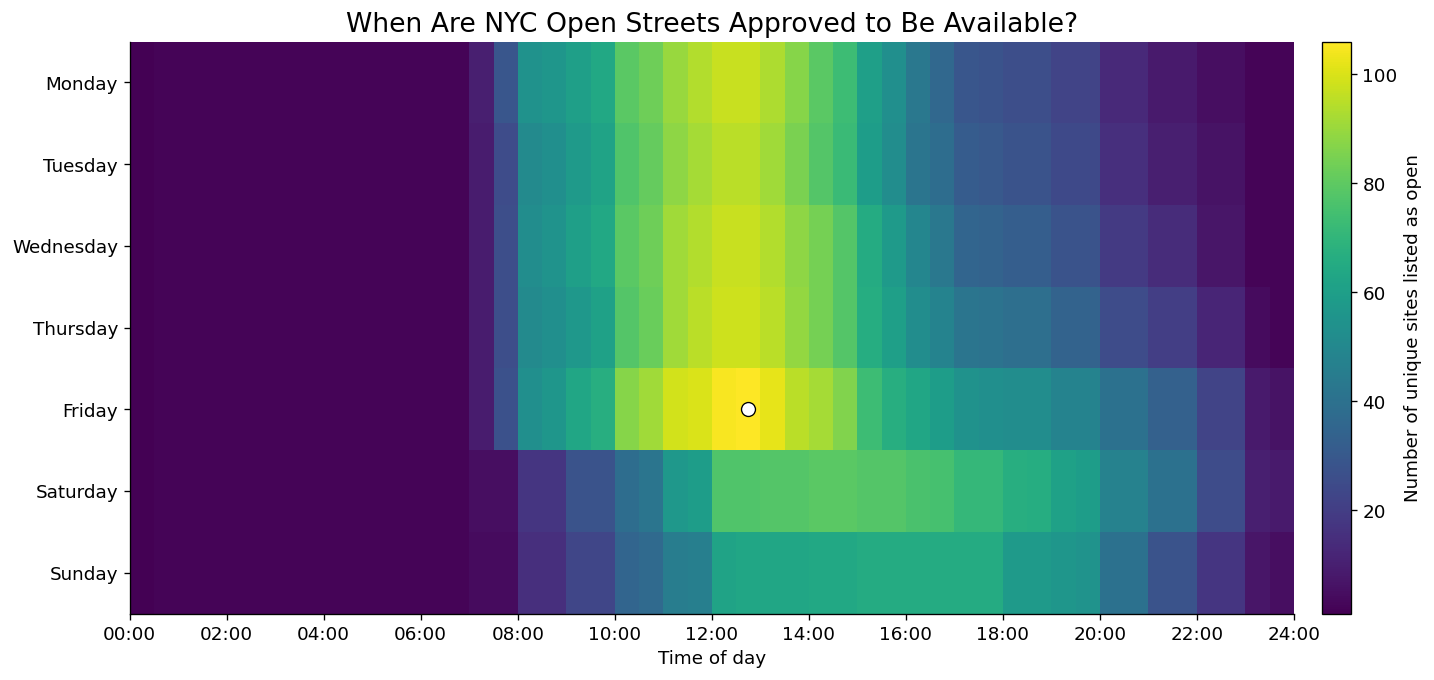

Peak overlap in this snapshot: 106 sites on Friday around 12:30.


In [8]:
slot_minutes = 30
slots = np.arange(0, 1440, slot_minutes)
availability = np.zeros((7, len(slots)), dtype=int)

for _, row in schedule.dropna(subset=["daily_open_hours"]).iterrows():
    day_idx = int(row["day_order"])
    active = (slots >= row["open_min"]) & (slots < row["close_min"])
    availability[day_idx, active] += 1

time_edges = np.arange(0, 1440 + slot_minutes, slot_minutes) / 60
day_edges = np.arange(8)

fig, ax = plt.subplots(figsize=(13, 5.8))
mesh = ax.pcolormesh(time_edges, day_edges, availability, shading="flat")
ax.set_ylim(7, 0)
ax.set_yticks(np.arange(7) + 0.5, labels=DAYS)
ax.set_xticks(np.arange(0, 25, 2))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 25, 2)])
ax.set_xlim(0, 24)
ax.set_xlabel("Time of day")
ax.set_title("When Are NYC Open Streets Approved to Be Available?")

cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label("Number of unique sites listed as open")

peak_index = np.unravel_index(np.argmax(availability), availability.shape)
peak_day = DAYS[peak_index[0]]
peak_minutes = slots[peak_index[1]]
peak_count = int(availability[peak_index])
peak_time = f"{peak_minutes // 60:02.0f}:{peak_minutes % 60:02.0f}"
ax.scatter(
    peak_minutes / 60 + slot_minutes / 120,
    peak_index[0] + 0.5,
    s=70,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_time_availability_heatmap.png", bbox_inches="tight")
plt.show()
print(f"Peak overlap in this snapshot: {peak_count} sites on {peak_day} around {peak_time}.")

**What the result shows**

- **Approved Open Street availability is concentrated mainly during daytime hours.**
- **On weekdays, availability rises around 8:00 AM and is highest between late morning and early afternoon.**
- **The greatest overlap appears around midday on Friday, when the largest number of sites are approved to be open at the same time.**
- **Weekend Open Streets generally begin later than weekday programs but remain available further into the evening.**
- **The pattern suggests that many Open Streets function as scheduled daytime programs rather than continuously available public spaces.**

### Visualization 2 — How long are Open Streets available on each listed day?

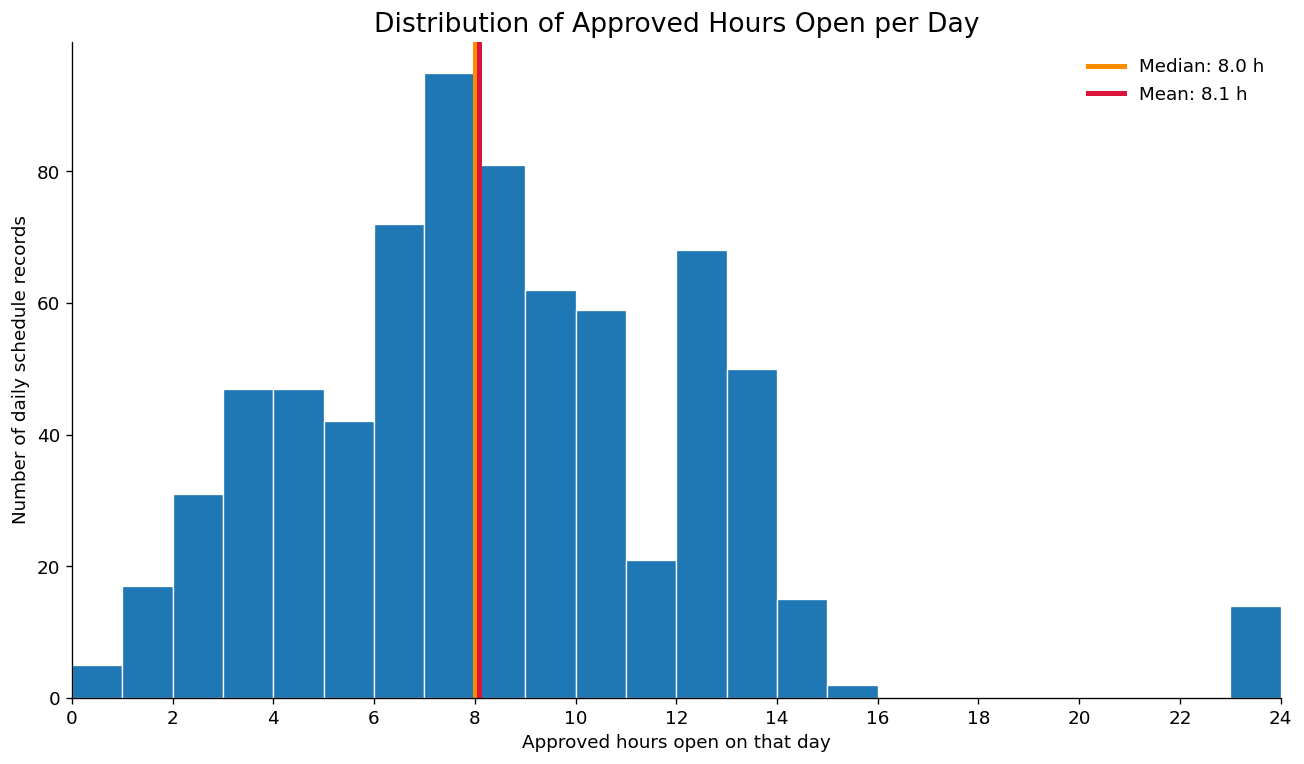

In [9]:
valid_daily_records = schedule.dropna(subset=["daily_open_hours"])
median_daily = valid_daily_records["daily_open_hours"].median()
mean_daily = valid_daily_records["daily_open_hours"].mean()

fig, ax = plt.subplots(figsize=(11, 6.5))
bins = np.arange(0, 25, 1)
ax.hist(
    valid_daily_records["daily_open_hours"],
    bins=bins,
    edgecolor="white",
    linewidth=0.8
)
ax.axvline(
    median_daily,
    color="darkorange",
    linestyle="-",
    linewidth=3,
    label=f"Median: {median_daily:.1f} h"
)
ax.axvline(
    mean_daily,
    color="crimson",
    linestyle="-",
    linewidth=3,
    label=f"Mean: {mean_daily:.1f} h"
)
ax.set_xlim(0, 24)
ax.set_xticks(np.arange(0, 25, 2))
ax.set_xlabel("Approved hours open on that day")
ax.set_ylabel("Number of daily schedule records")
ax.set_title("Distribution of Approved Hours Open per Day")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_daily_hours_distribution.png", bbox_inches="tight")
plt.show()

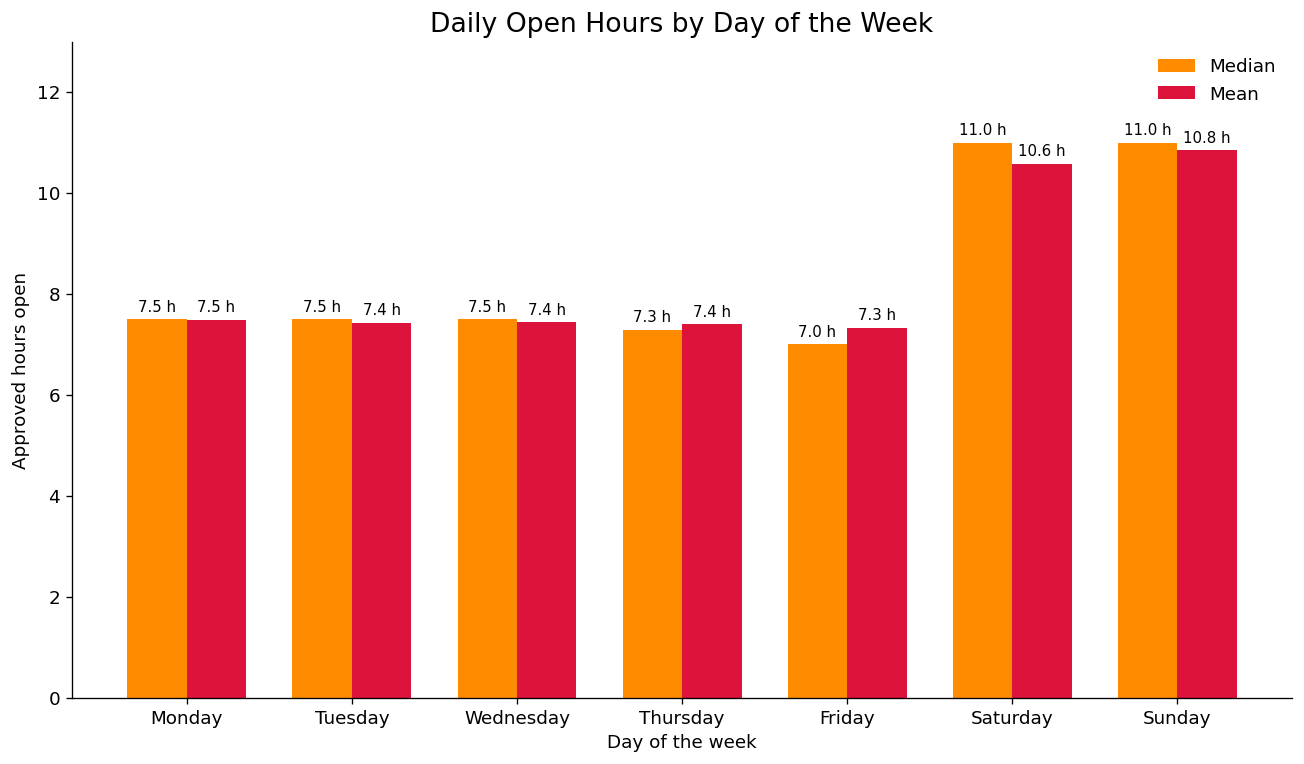

,day,median_hours,mean_hours,records
0,Monday,7.5,7.5,105
1,Tuesday,7.5,7.4,105
2,Wednesday,7.5,7.4,112
3,Thursday,7.3,7.4,118
4,Friday,7.0,7.3,139
5,Saturday,11.0,10.6,82
6,Sunday,11.0,10.8,67


In [10]:
by_day = (
    valid_daily_records.groupby("day")["daily_open_hours"]
    .agg(median_hours="median", mean_hours="mean", records="count")
    .reindex(DAYS)
    .reset_index()
)

x = np.arange(len(by_day))
bar_width = 0.36
fig, ax = plt.subplots(figsize=(11, 6.5))
median_bars = ax.bar(
    x - bar_width / 2,
    by_day["median_hours"],
    width=bar_width,
    color="darkorange",
    label="Median"
)
mean_bars = ax.bar(
    x + bar_width / 2,
    by_day["mean_hours"],
    width=bar_width,
    color="crimson",
    label="Mean"
)
ax.set_xticks(x, labels=by_day["day"])
ax.set_ylabel("Approved hours open")
ax.set_xlabel("Day of the week")
ax.set_title("Daily Open Hours by Day of the Week")
ax.set_ylim(0, max(by_day["median_hours"].max(), by_day["mean_hours"].max()) + 2)
ax.bar_label(median_bars, fmt="%.1f h", padding=3, fontsize=9)
ax.bar_label(mean_bars, fmt="%.1f h", padding=3, fontsize=9)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_daily_hours_by_weekday.png", bbox_inches="tight")
plt.show()

display(by_day.round(1))

### Visualization 3 — How many approved hours does each site provide over its full listed period?

This comparison includes site's schedule duration between its approved start and end dates. It is intended to represent longer-term scheduled availability.

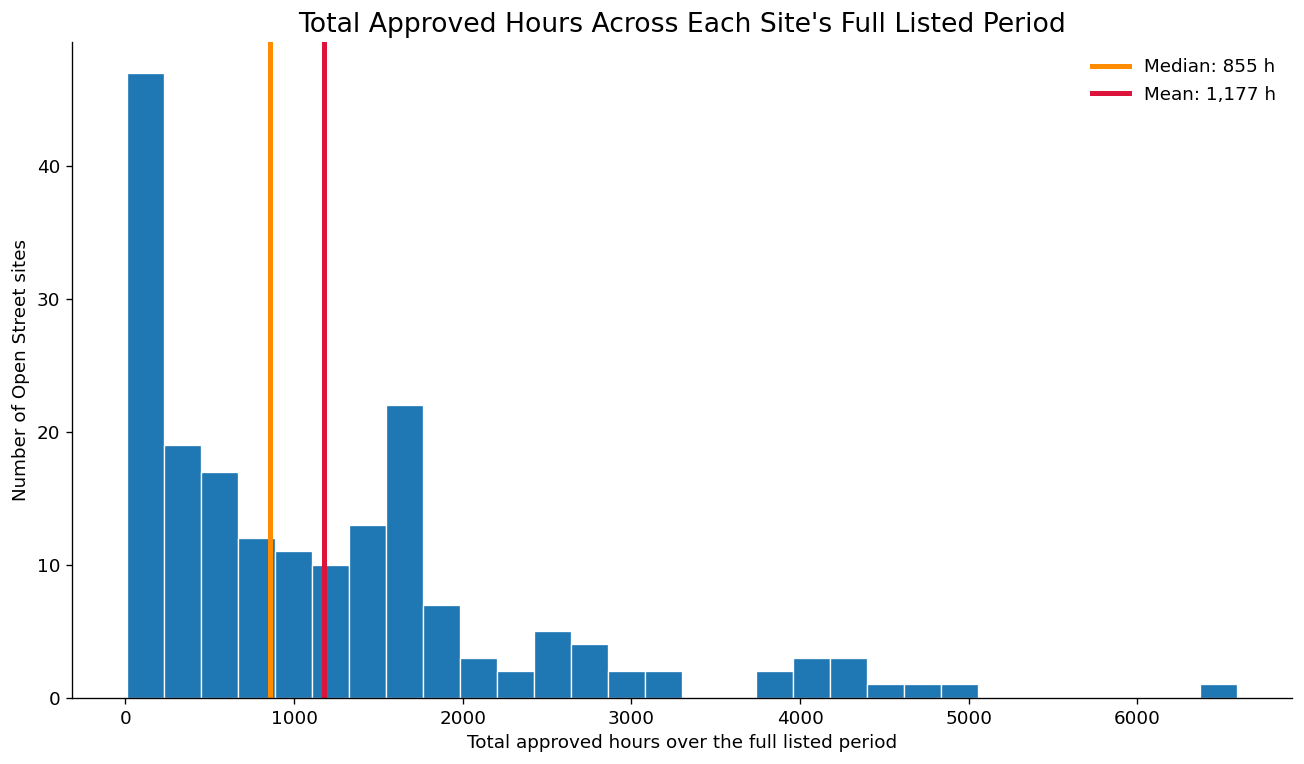

Median total approved time: 855 hours
Mean total approved time: 1,177 hours


In [11]:
valid_full_period = sites.dropna(subset=["total_approved_hours"]).copy()
median_total = valid_full_period["total_approved_hours"].median()
mean_total = valid_full_period["total_approved_hours"].mean()

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.hist(
    valid_full_period["total_approved_hours"],
    bins=30,
    edgecolor="white",
    linewidth=0.8
)
ax.axvline(
    median_total,
    color="darkorange",
    linestyle="-",
    linewidth=3,
    label=f"Median: {median_total:,.0f} h"
)
ax.axvline(
    mean_total,
    color="crimson",
    linestyle="-",
    linewidth=3,
    label=f"Mean: {mean_total:,.0f} h"
)
ax.set_xlabel("Total approved hours over the full listed period")
ax.set_ylabel("Number of Open Street sites")
ax.set_title("Total Approved Hours Across Each Site's Full Listed Period")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_full_period_hours_distribution.png", bbox_inches="tight")
plt.show()

print(f"Median total approved time: {median_total:,.0f} hours")
print(f"Mean total approved time: {mean_total:,.0f} hours")

# Part II — Spatial Distribution
## Where are NYC Open Streets located?

Distribution is examined in three ways:

- the **number of distinct sites**;
- the **mapped length** of Open Street segments; and
- the **density of sites relative to borough land area**.

Using both totals and normalized measures avoids treating a small borough and a large borough as directly comparable only by raw counts.

In [12]:
# Prepare official borough polygons and project all geometry to NYC State Plane feet.
boroughs = gpd.GeoDataFrame(
    borough_raw.copy(),
    geometry=borough_raw["the_geom"].map(wkt.loads),
    crs="EPSG:4326"
).to_crs("EPSG:2263")

sites_map = sites.to_crs("EPSG:2263").copy()
sites_map["site_length_miles"] = sites_map.length / 5280
sites_map["borough_area_sqmi"] = sites_map["Borough Name"].map(
    boroughs.set_index("BoroName").geometry.area.div(5280 ** 2)
)

borough_distribution = (
    sites_map.groupby("Borough Name", as_index=False)
    .agg(
        site_count=("site_id", "nunique"),
        open_street_miles=("site_length_miles", "sum"),
        total_approved_hours=("total_approved_hours", "sum"),
    )
)

borough_area = boroughs.assign(
    borough_area_sqmi=boroughs.geometry.area / 5280 ** 2
)[["BoroName", "borough_area_sqmi"]]

borough_distribution = borough_distribution.merge(
    borough_area,
    left_on="Borough Name",
    right_on="BoroName",
    how="left"
).drop(columns="BoroName")

borough_distribution["sites_per_10_sqmi"] = (
    borough_distribution["site_count"] / borough_distribution["borough_area_sqmi"] * 10
)
borough_distribution["open_street_miles_per_10_sqmi"] = (
    borough_distribution["open_street_miles"] / borough_distribution["borough_area_sqmi"] * 10
)

display(
    borough_distribution.sort_values("site_count", ascending=False).round(2)
)

,Borough Name,site_count,open_street_miles,total_approved_hours,borough_area_sqmi,sites_per_10_sqmi,open_street_miles_per_10_sqmi
2,Manhattan,74,8.42,92732.82,22.84,32.40,3.69
1,Brooklyn,52,8.42,62038.17,69.39,7.49,1.21
3,Queens,33,5.50,47824.33,109.10,3.02,0.50
0,Bronx,23,1.99,14179.00,42.58,5.40,0.47
4,Staten Island,6,0.49,4516.00,58.24,1.03,0.08


### Visualization 4 — Location and longer-term approved time

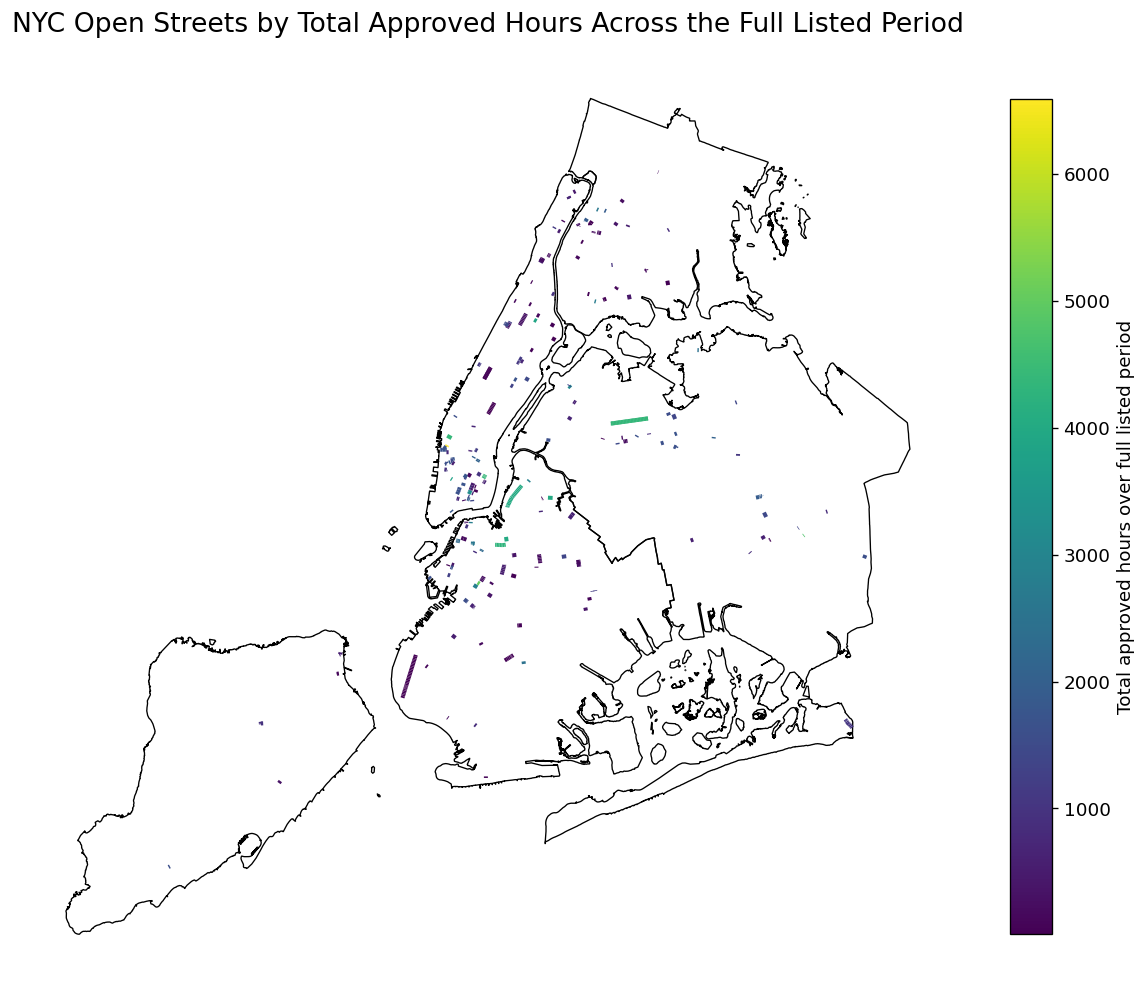

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
boroughs.plot(ax=ax, facecolor="none", linewidth=0.8)
sites_map.plot(
    ax=ax,
    column="total_approved_hours",
    linewidth=2.4,
    legend=True,
    legend_kwds={"label": "Total approved hours over full listed period", "shrink": 0.72}
)
ax.set_axis_off()
ax.set_title("NYC Open Streets by Total Approved Hours Across the Full Listed Period", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_sites_by_full_period_hours_map.png", bbox_inches="tight")
plt.show()

### Visualization 5 — How many distinct sites are listed in each borough?

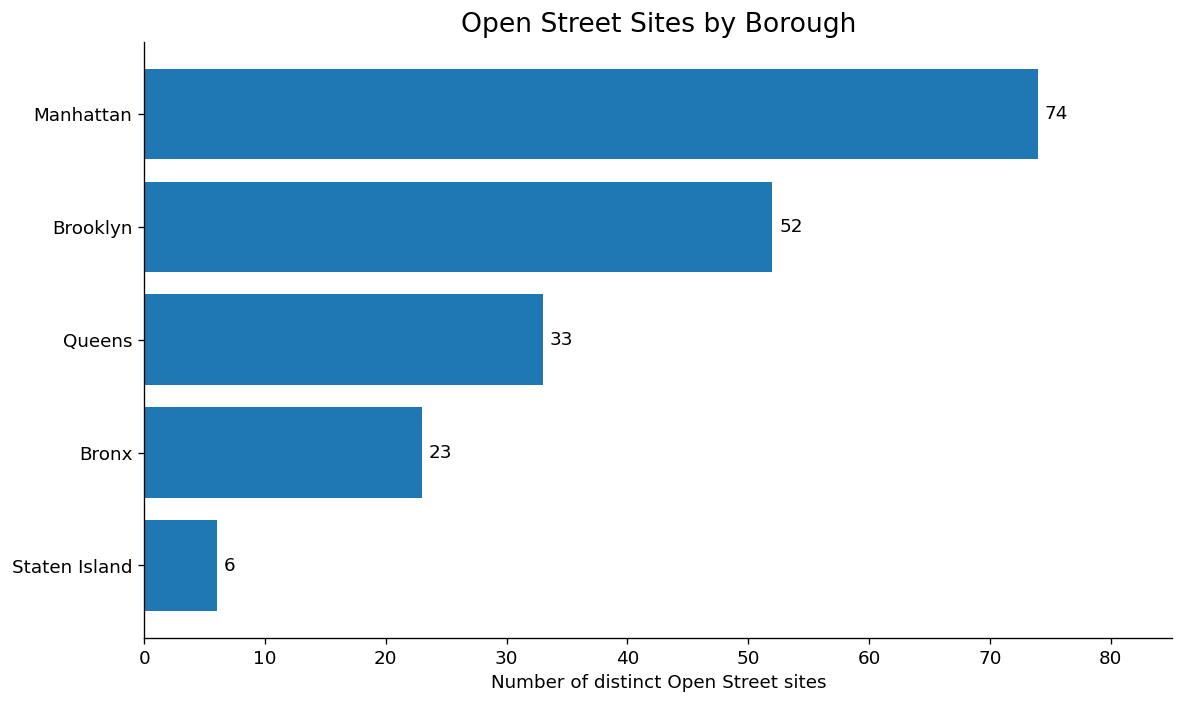

In [14]:
plot_data = borough_distribution.sort_values("site_count")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data["Borough Name"], plot_data["site_count"])
ax.set_xlabel("Number of distinct Open Street sites")
ax.set_ylabel("")
ax.set_title("Open Street Sites by Borough")
ax.bar_label(bars, padding=4)
ax.set_xlim(0, plot_data["site_count"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_site_count_by_borough.png", bbox_inches="tight")
plt.show()

### Visualization 6 — How dense is the distribution relative to borough area?

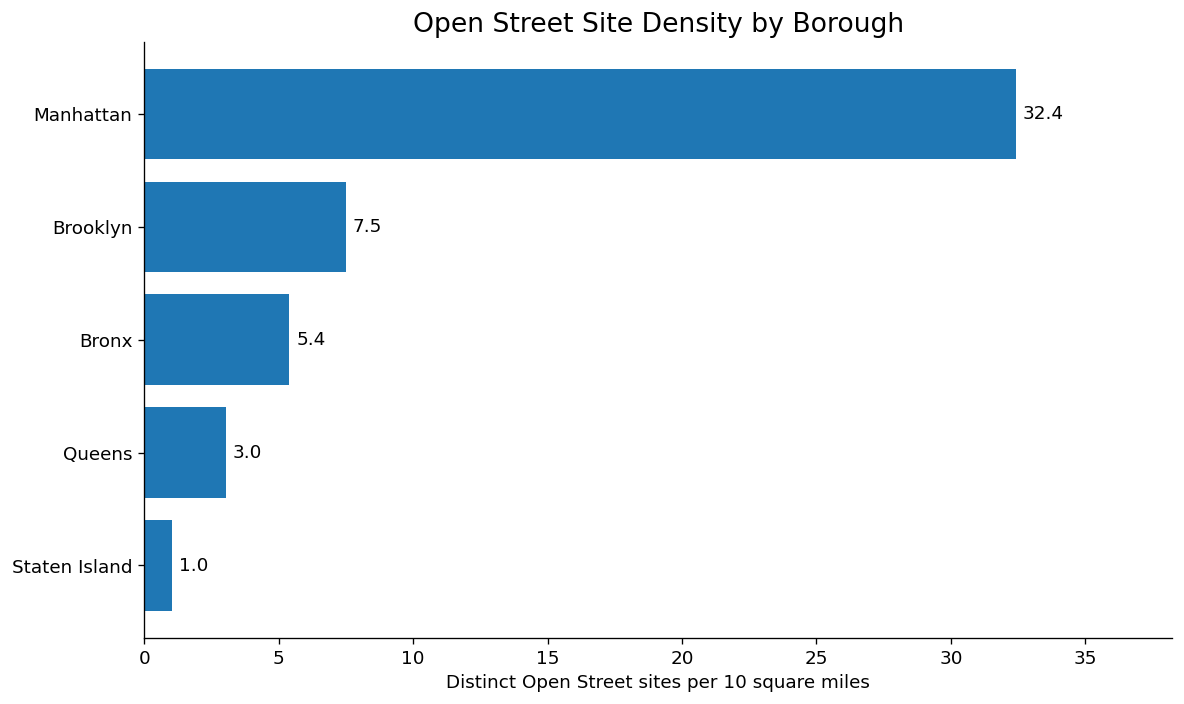

In [15]:
plot_data = borough_distribution.sort_values("sites_per_10_sqmi")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data["Borough Name"], plot_data["sites_per_10_sqmi"])
ax.set_xlabel("Distinct Open Street sites per 10 square miles")
ax.set_ylabel("")
ax.set_title("Open Street Site Density by Borough")
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_xlim(0, plot_data["sites_per_10_sqmi"].max() * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_site_density_by_borough.png", bbox_inches="tight")
plt.show()

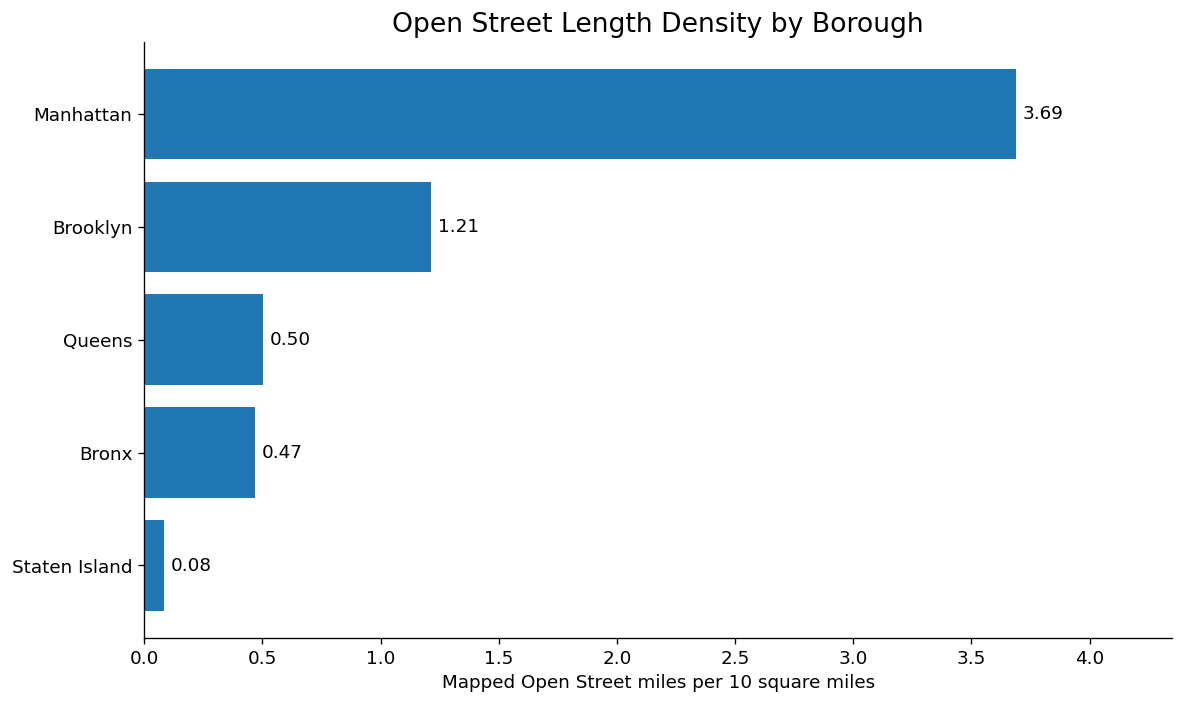

In [16]:
plot_data = borough_distribution.sort_values("open_street_miles_per_10_sqmi")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data["Borough Name"], plot_data["open_street_miles_per_10_sqmi"])
ax.set_xlabel("Mapped Open Street miles per 10 square miles")
ax.set_ylabel("")
ax.set_title("Open Street Length Density by Borough")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_xlim(0, plot_data["open_street_miles_per_10_sqmi"].max() * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_length_density_by_borough.png", bbox_inches="tight")
plt.show()

### Visualization 7 — Where are sites spatially concentrated?

This map uses the midpoint of each distinct Open Street to show local concentrations. It is a distribution view, not a measure of pedestrian demand or program quality.

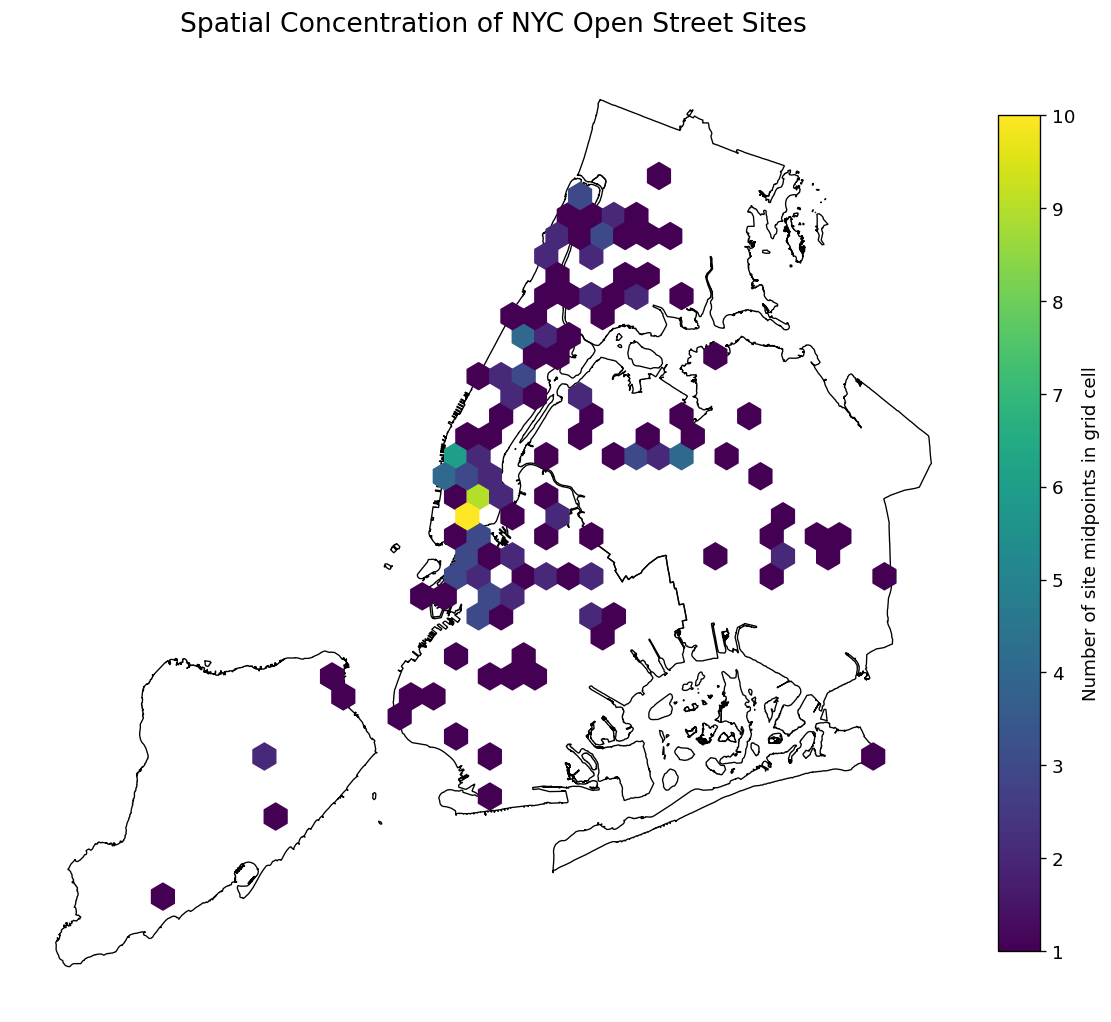

In [17]:
site_midpoints = sites_map.copy()
site_midpoints["geometry"] = site_midpoints.geometry.centroid

fig, ax = plt.subplots(figsize=(10, 10))
boroughs.plot(ax=ax, facecolor="none", linewidth=0.8)
hexbin = ax.hexbin(
    site_midpoints.geometry.x,
    site_midpoints.geometry.y,
    gridsize=32,
    mincnt=1
)
cbar = fig.colorbar(hexbin, ax=ax, pad=0.02, shrink=0.72)
cbar.set_label("Number of site midpoints in grid cell")
ax.set_axis_off()
ax.set_title("Spatial Concentration of NYC Open Street Sites", pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_site_concentration_hexbin.png", bbox_inches="tight")
plt.show()

**Distribution interpretation**

Raw counts and normalized density tell different stories. A borough may contain many sites because it is large, while another may provide a much denser network relative to its land area. These measures describe where the program is listed, but they do not yet show whether people can conveniently reach a site.

# Part III — Approximate Ten-Minute Walking Access
## Which areas have potential access to an Open Street?

This notebook uses a transparent approximation:

- assumed walking speed: **80 meters per minute**;
- ten-minute distance: **800 meters**;
- access area: an 800-meter buffer around the **entire Open Street line**, not only its midpoint.

This is a **straight-line approximation**, not a pedestrian-network isochrone. It can cross barriers such as highways, rail infrastructure, water, or inaccessible blocks. The resulting area should therefore be described as **potential approximate access**, not a precise walking route.

In [18]:
WALK_MINUTES = 10
ASSUMED_METERS_PER_MINUTE = 80
WALK_DISTANCE_METERS = WALK_MINUTES * ASSUMED_METERS_PER_MINUTE
WALK_DISTANCE_FEET = WALK_DISTANCE_METERS * 3.280839895

# Buffer each complete Open Street line, then merge overlaps and clip to NYC land.
site_access = gpd.GeoDataFrame(
    sites_map[["site_id", "Borough Name", "program_type"]].copy(),
    geometry=sites_map.geometry.buffer(WALK_DISTANCE_FEET),
    crs=sites_map.crs
)

city_geometry = unary_union(boroughs.geometry)
city_access_geometry = unary_union(site_access.geometry).intersection(city_geometry)
city_access = gpd.GeoDataFrame(
    {"access_minutes": [10], "geometry": [city_access_geometry]},
    crs=sites_map.crs
)

city_area_sqmi = city_geometry.area / 5280 ** 2
access_area_sqmi = city_access_geometry.area / 5280 ** 2
city_access_percent = city_access_geometry.area / city_geometry.area * 100

access_by_borough = []
for _, borough in boroughs.iterrows():
    clipped_access = city_access_geometry.intersection(borough.geometry)
    access_by_borough.append({
        "Borough Name": borough["BoroName"],
        "borough_area_sqmi": borough.geometry.area / 5280 ** 2,
        "approx_access_area_sqmi": clipped_access.area / 5280 ** 2,
        "approx_access_percent": clipped_access.area / borough.geometry.area * 100,
    })

access_by_borough = pd.DataFrame(access_by_borough)
borough_access_summary = borough_distribution.merge(
    access_by_borough,
    on=["Borough Name", "borough_area_sqmi"],
    how="left"
)

display(
    borough_access_summary.sort_values("approx_access_percent", ascending=False).round(2)
)

print(f"Approximate city land area within 800 m of at least one listed site: {access_area_sqmi:,.1f} sq mi")
print(f"Approximate share of NYC land area covered: {city_access_percent:.1f}%")

,Borough Name,site_count,open_street_miles,total_approved_hours,borough_area_sqmi,sites_per_10_sqmi,open_street_miles_per_10_sqmi,approx_access_area_sqmi,approx_access_percent
2,Manhattan,74,8.42,92732.82,22.84,32.40,3.69,18.55,81.22
1,Brooklyn,52,8.42,62038.17,69.39,7.49,1.21,25.17,36.28
0,Bronx,23,1.99,14179.00,42.58,5.40,0.47,11.95,28.06
3,Queens,33,5.50,47824.33,109.10,3.02,0.50,19.29,17.68
4,Staten Island,6,0.49,4516.00,58.24,1.03,0.08,3.72,6.39


Approximate city land area within 800 m of at least one listed site: 78.7 sq mi
Approximate share of NYC land area covered: 26.0%


### Visualization 8 — Approximate ten-minute access area

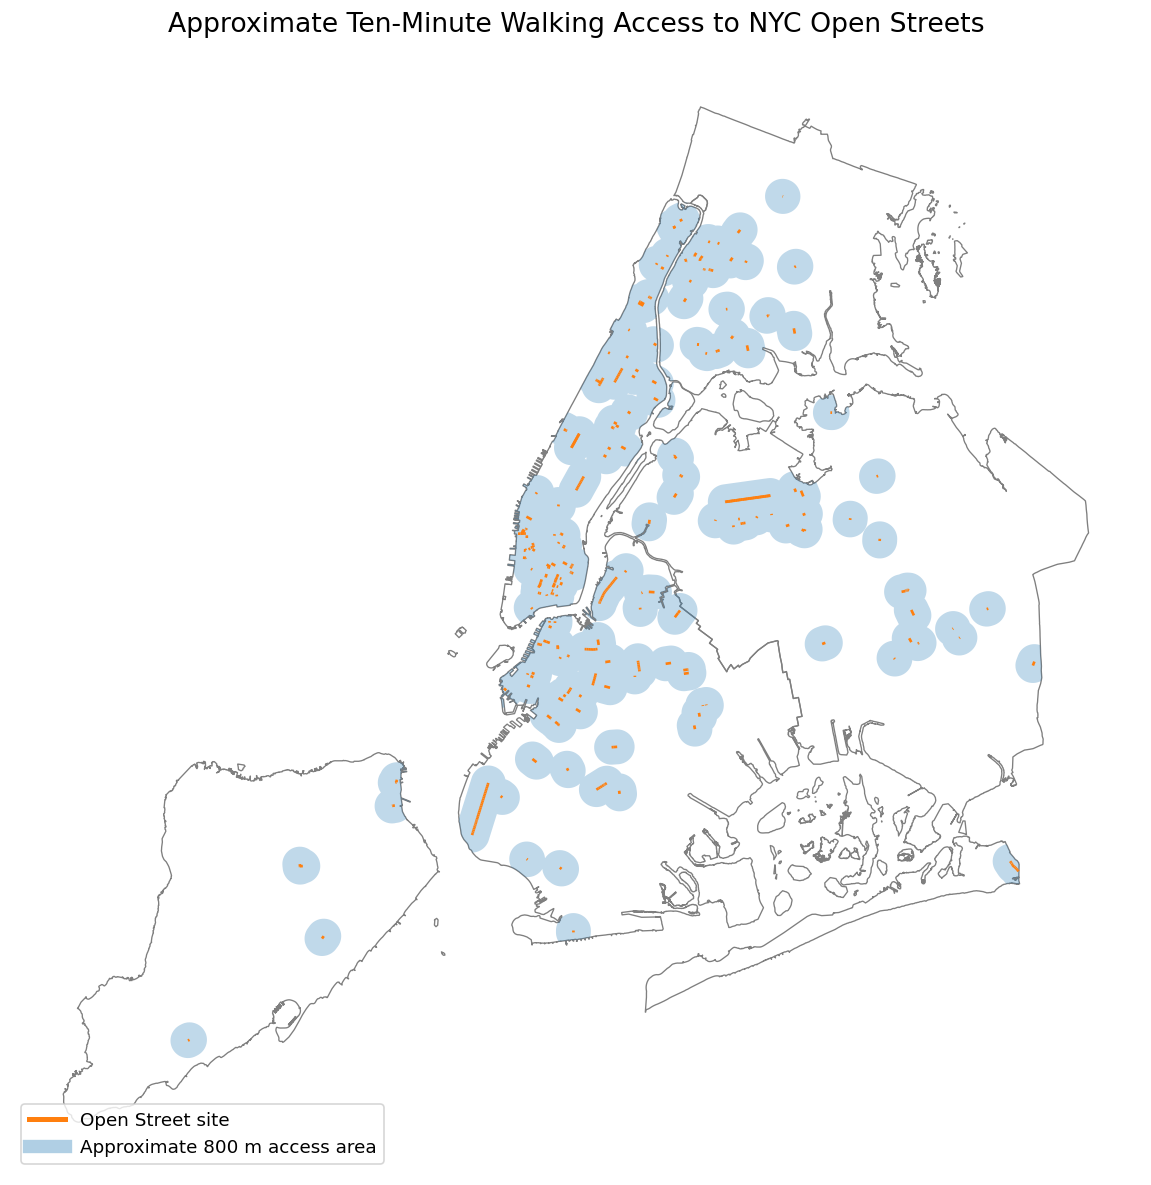

In [19]:
cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, ax = plt.subplots(figsize=(10, 10))
boroughs.plot(ax=ax, facecolor="none", edgecolor=cycle[7], linewidth=0.8)
city_access.plot(ax=ax, color=cycle[0], alpha=0.28, edgecolor="none")
sites_map.plot(ax=ax, color=cycle[1], linewidth=1.6)
ax.set_axis_off()
ax.set_title("Approximate Ten-Minute Walking Access to NYC Open Streets", pad=15)
legend_handles = [
    Line2D([0], [0], color=cycle[1], lw=3, label="Open Street site"),
    Line2D([0], [0], color=cycle[0], lw=8, alpha=0.35, label="Approximate 800 m access area"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_approx_10min_access_map.png", bbox_inches="tight")
plt.show()

### Visualization 9 — What share of each borough's land is near a listed Open Street?

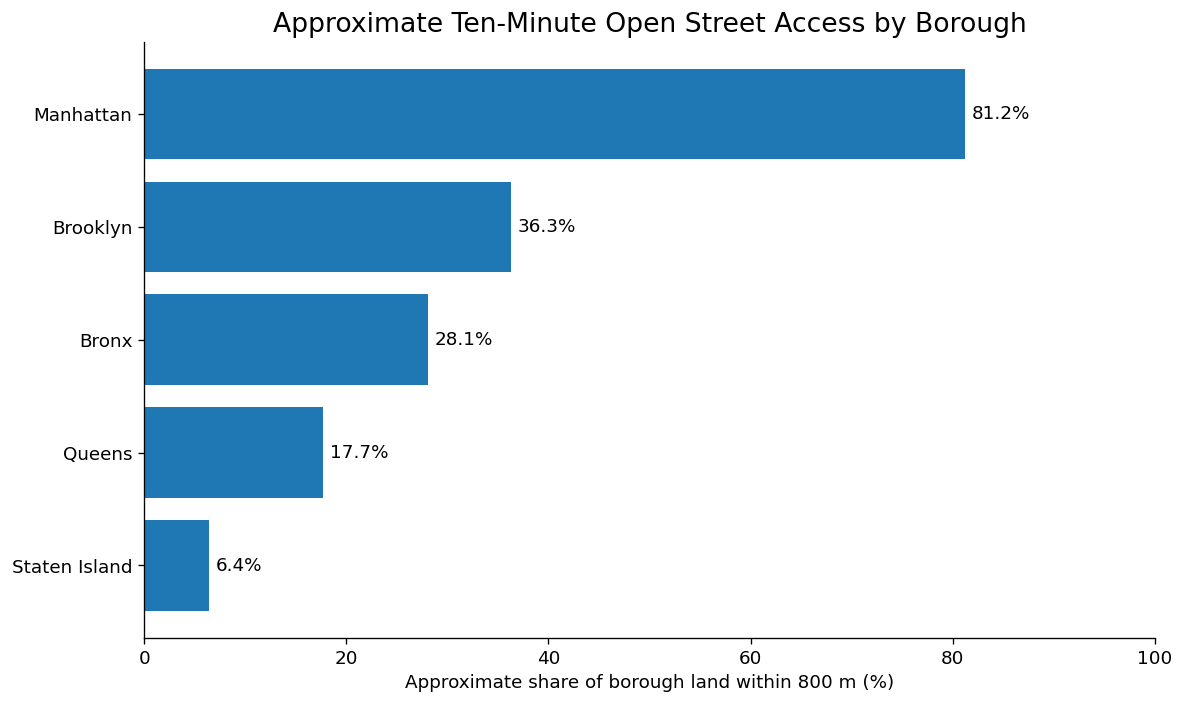

In [20]:
plot_data = borough_access_summary.sort_values("approx_access_percent")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data["Borough Name"], plot_data["approx_access_percent"])
ax.set_xlabel("Approximate share of borough land within 800 m (%)")
ax.set_ylabel("")
ax.set_title("Approximate Ten-Minute Open Street Access by Borough")
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_access_share_by_borough.png", bbox_inches="tight")
plt.show()

## Combining total approved time and approximate access

The access area around every Open Street is not equivalent in temporal availability. Some sites are listed for only a short period, while others provide many more approved hours across their full listed dates.

The next visualization combines these two dimensions:

- **geometry:** the approximate 800-meter access area around each Open Street;
- **color:** the site's estimated total approved hours across its full listed period.

Darker areas represent potential access to an Open Street with more cumulative approved time. This does not mean that hours from overlapping areas should be added together.

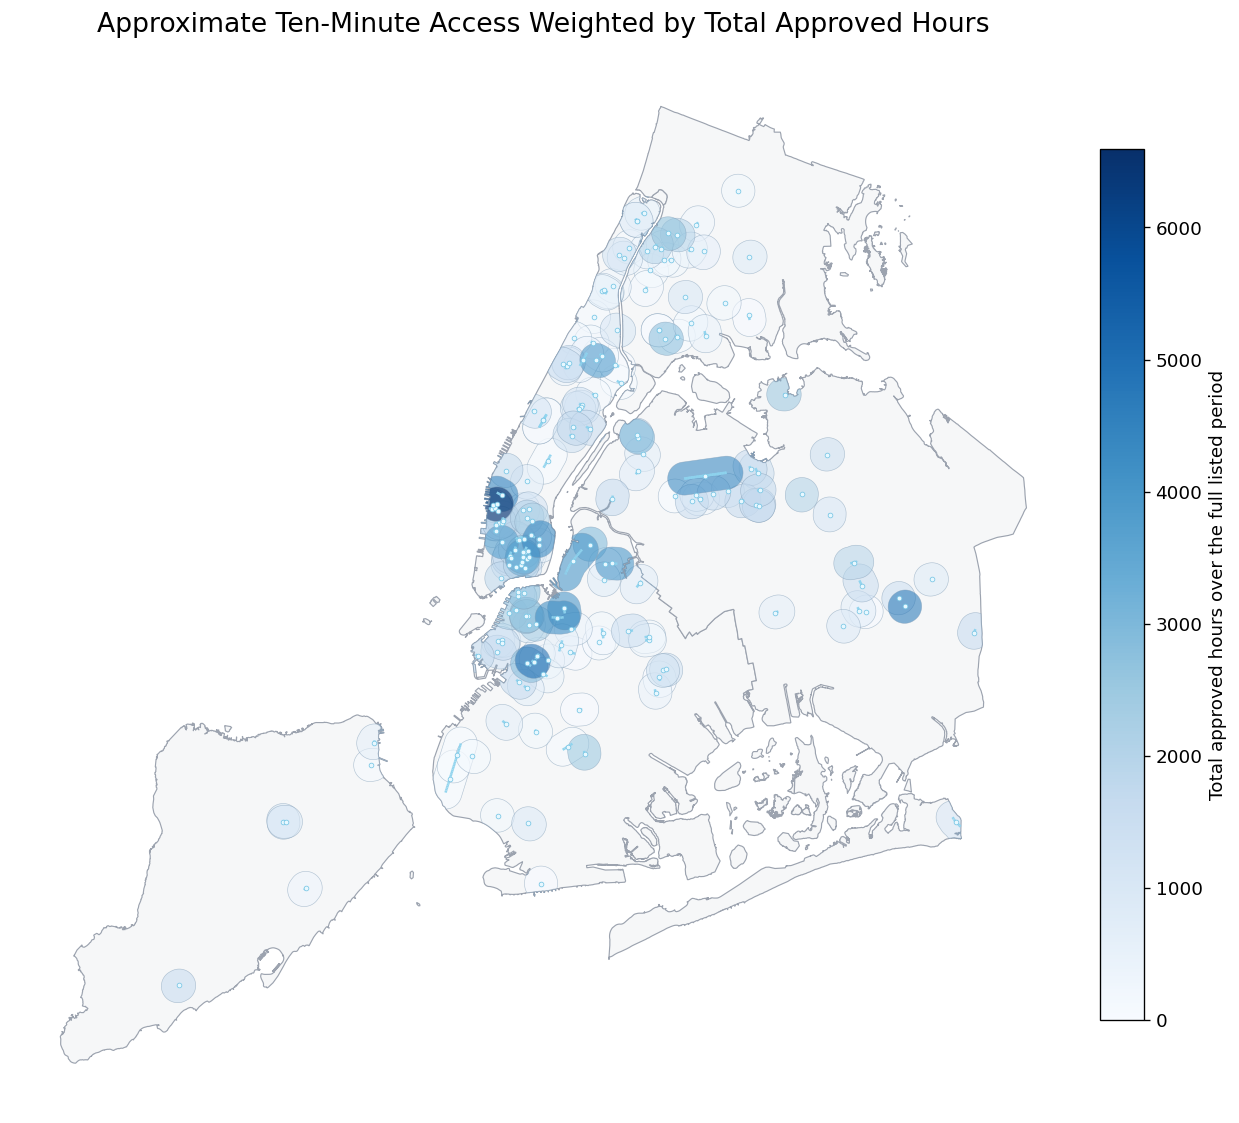

In [21]:
# Join each site's approved-time attributes to its approximate access area.
walkshed_attributes = sites_map[[
    "site_id",
    "Approved On Street",
    "Approved From Street",
    "Approved To Street",
    "Borough Name",
    "program_type",
    "Organization Name",
    "approved_start_date",
    "approved_end_date",
    "approved_days_per_week",
    "weekly_approved_hours",
    "total_approved_hours",
]].drop(columns="geometry", errors="ignore")

weighted_walksheds = site_access[["site_id", "geometry"]].merge(
    walkshed_attributes,
    on="site_id",
    how="left"
)
weighted_walksheds = gpd.GeoDataFrame(
    weighted_walksheds,
    geometry="geometry",
    crs=site_access.crs
)

# Clip each site-specific access area to NYC land.
weighted_walksheds["geometry"] = weighted_walksheds.geometry.intersection(city_geometry)
weighted_walksheds = weighted_walksheds.loc[
    ~weighted_walksheds.geometry.is_empty
].dropna(subset=["total_approved_hours"]).copy()

# Draw lower-hour areas first so higher-hour areas remain visible on top.
weighted_walksheds = weighted_walksheds.sort_values("total_approved_hours")

valid_hours = weighted_walksheds["total_approved_hours"]
norm = Normalize(vmin=0, vmax=float(valid_hours.max()))
cmap = plt.get_cmap("Blues")

fig, ax = plt.subplots(figsize=(11, 11))

boroughs.plot(
    ax=ax,
    facecolor="#f6f7f8",
    edgecolor="#9ca3af",
    linewidth=0.7,
    zorder=1
)

weighted_walksheds.plot(
    ax=ax,
    column="total_approved_hours",
    cmap=cmap,
    norm=norm,
    alpha=0.58,
    edgecolor="#7e9bb5",
    linewidth=0.35,
    zorder=2
)

# Open Street lines and representative points use a pale blue accent.
sites_map.loc[
    sites_map["site_id"].isin(weighted_walksheds["site_id"])
].plot(
    ax=ax,
    color="#8ed3ee",
    linewidth=1.5,
    alpha=0.95,
    zorder=3
)

site_points = sites_map.loc[
    sites_map["site_id"].isin(weighted_walksheds["site_id"])
].copy()
site_points["geometry"] = site_points.geometry.representative_point()
site_points.plot(
    ax=ax,
    facecolor="#e8f8ff",
    edgecolor="#76c5e4",
    linewidth=0.45,
    markersize=8,
    zorder=4
)

colorbar = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    shrink=0.68,
    pad=0.02
)
colorbar.set_label("Total approved hours over the full listed period")

ax.set_axis_off()
ax.set_title(
    "Approximate Ten-Minute Access Weighted by Total Approved Hours",
    pad=16
)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "12_walksheds_weighted_by_total_hours.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Accessibility interpretation**

- The 800-meter areas show approximate geographic proximity to each listed Open Street.
- Darker areas correspond to sites with more total approved hours across their full listed periods.
- The color does not measure attendance, quality, or confirmed operation.
- Where polygons overlap, visual darkness can increase because several access areas occupy the same location; the overlap should not be read as a direct sum of hours.
- The separate interactive map allows a user to filter the same dataset by a specific date and time, ZIP Code, or both.

## Interactive Web Map

In [22]:
# ============================================================
# Export data for the separate interactive web map
# ============================================================

# Add browser-friendly dates and one flat set of schedule fields per weekday.
sites_web = sites.to_crs("EPSG:4326").copy()
sites_web["approved_start"] = sites_web["approved_start_date"].dt.strftime("%Y-%m-%d")
sites_web["approved_end"] = sites_web["approved_end_date"].dt.strftime("%Y-%m-%d")

valid_schedule = schedule.loc[schedule["time_flag"] == "ok"].copy()
schedule_fields = []

for day in DAYS:
    day_key = day.lower()
    day_schedule = (
        valid_schedule.loc[valid_schedule["day"] == day]
        .drop_duplicates(subset="site_id")
        .set_index("site_id")
    )

    open_field = f"{day_key}_open_min"
    close_field = f"{day_key}_close_min"
    label_field = f"{day_key}_schedule"

    sites_web[open_field] = sites_web["site_id"].map(day_schedule["open_min"])
    sites_web[close_field] = sites_web["site_id"].map(day_schedule["close_min"])
    sites_web[label_field] = sites_web["site_id"].map(
        day_schedule.apply(
            lambda row: f"{row['open_time']}–{row['close_time']}",
            axis=1
        )
    )
    schedule_fields.extend([open_field, close_field, label_field])

web_fields = [
    "site_id",
    "Approved On Street",
    "Approved From Street",
    "Approved To Street",
    "Borough Name",
    "program_type",
    "Organization Name",
    "approved_start",
    "approved_end",
    "approved_days_per_week",
    "weekly_approved_hours",
    "total_approved_hours",
] + schedule_fields + ["geometry"]

sites_web = sites_web[web_fields].copy()

# One filterable access polygon per site, carrying the same properties.
site_properties = sites_web.drop(columns="geometry")
walksheds_web = weighted_walksheds[["site_id", "geometry"]].merge(
    site_properties,
    on="site_id",
    how="left"
)
walksheds_web = gpd.GeoDataFrame(
    walksheds_web,
    geometry="geometry",
    crs=weighted_walksheds.crs
).to_crs("EPSG:4326")
walksheds_web = walksheds_web.sort_values("total_approved_hours")

# One small reference point per Open Street line.
markers_web = sites_web.copy()
markers_web["geometry"] = markers_web.geometry.representative_point()

# Simplify borough outlines for faster web rendering.
boroughs_web = boroughs[["BoroName", "geometry"]].copy()
boroughs_web["geometry"] = boroughs_web.geometry.simplify(50, preserve_topology=True)
boroughs_web = boroughs_web.to_crs("EPSG:4326")


def export_geojson(gdf, filename):
    output_path = WEBMAP_DATA_DIR / filename
    output_path.write_text(
        gdf.to_json(drop_id=True),
        encoding="utf-8"
    )
    return output_path


exported_files = [
    export_geojson(sites_web, "open_streets.geojson"),
    export_geojson(walksheds_web, "walksheds.geojson"),
    export_geojson(markers_web, "reference_points.geojson"),
    export_geojson(boroughs_web, "borough_boundaries.geojson"),
]

# Keep reusable analysis outputs outside the web folder as well.
(OUTPUT_DIR / "open_streets_processed.geojson").write_text(
    sites_web.to_json(drop_id=True),
    encoding="utf-8"
)
(OUTPUT_DIR / "walksheds_weighted_by_total_approved_hours.geojson").write_text(
    walksheds_web.to_json(drop_id=True),
    encoding="utf-8"
)
borough_access_summary.to_csv(
    OUTPUT_DIR / "borough_access_summary.csv",
    index=False
)

export_summary = pd.DataFrame({
    "Web map file": [path.name for path in exported_files],
    "Features": [
        len(sites_web),
        len(walksheds_web),
        len(markers_web),
        len(boroughs_web),
    ],
    "Folder": [str(WEBMAP_DATA_DIR)] * 4,
})

display(export_summary)
print("Interactive map files are separate from the notebook:")
print(WEBMAP_DIR / "index.html")

,Web map file,Features,Folder
0,open_streets.geojson,188,web/webmap/data
1,walksheds.geojson,188,web/webmap/data
2,reference_points.geojson,188,web/webmap/data
3,borough_boundaries.geojson,5,web/webmap/data


Interactive map files are separate from the notebook:
web/webmap/index.html


# What this analysis can and cannot establish

## The data can describe

- where Open Street sites are mapped;
- their listed program type, dates, days, and times;
- how long they are approved to be open on a listed day;
- estimated total approved hours across the full listed period;
- borough-level differences in site count, length, density, and approximate access area;
- which site-specific access areas correspond to longer or shorter total approved time;
- which sites match a selected date and time or ZIP Code in the separate interactive map.

## The data cannot establish

- whether every site actually opened according to its schedule;
- whether barriers and staffing were consistently present;
- actual pedestrian routes or travel times;
- accessibility for people with different mobility needs;
- visitor counts, participation, safety, comfort, or program quality;
- whether all activities at a school-focused site were intended for the general public;
- the population that actually used or benefited from each site.

The 800-meter measure is intentionally labeled **approximate**. A future network-based version should use pedestrian routes, crossings, entrances, and barriers rather than straight-line buffers.

# Conclusion

This analysis shows that Open Streets should not be evaluated only as lines on a city map. Their public-space value is shaped by three connected dimensions:

1. **Time** — when and for how long a site is approved to be open;
2. **Distribution** — where sites and street length are concentrated;
3. **Access** — which areas are geographically close to sites, and how much approved public-space time those nearby sites provide over their full listed periods.

A static location map can overstate access because proximity alone does not describe how long a site remains available. Combining site-specific walksheds with total approved hours provides a clearer comparison between short-duration and longer-running Open Streets. The separate interactive map adds a practical exploration layer by allowing users to search by date and time, ZIP Code, or both.